In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('without_rules')

In [37]:
#Выгодная позиция для A
winner_A = pd.concat([
    df[df['Subscription'] == 'A'].nlargest(200, 'Videos Watched'),
    df[df['Subscription'] == 'B'].nsmallest(200, 'Videos Watched')
])
df['Selection Winner A'] = df.index.isin(winner_A.index).astype(int)

#Выгодная позиция для B
winner_B = pd.concat([
    df[df['Subscription'] == 'B'].nlargest(200, 'Videos Watched'),
    df[df['Subscription'] == 'A'].nsmallest(200, 'Videos Watched')
])
df['Selection Winner B'] = df.index.isin(winner_B.index).astype(int)

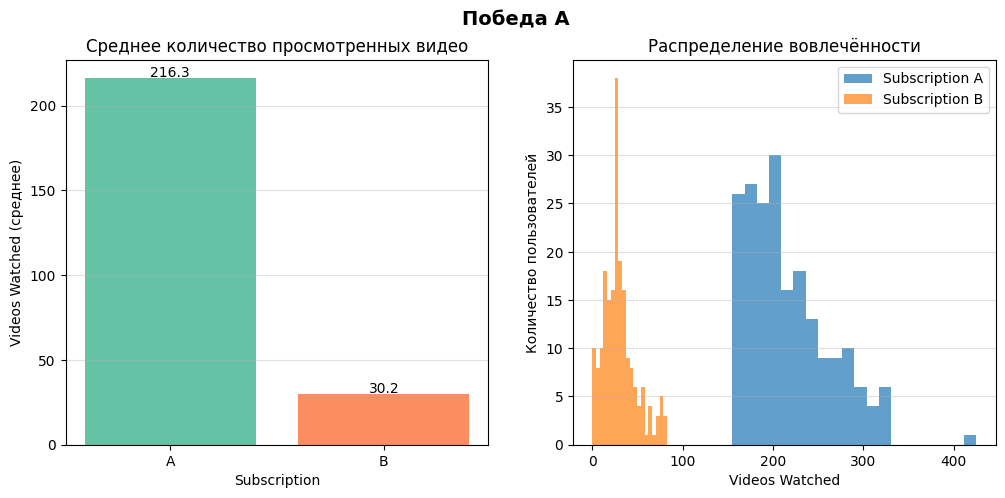

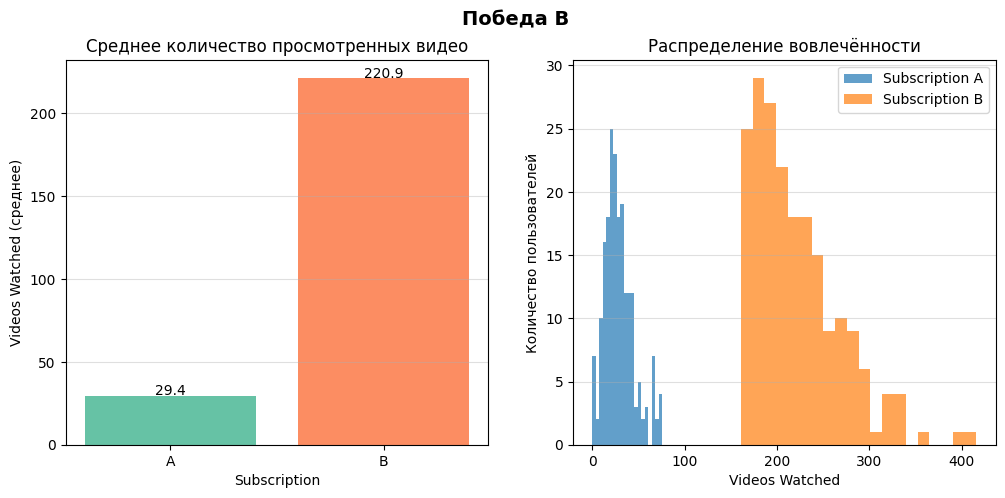

In [38]:
#Средняя вовлеченность и вывод графиков
def plot_combined(selection_col, title):
    subset = df[df[selection_col] == 1]
    means = subset.groupby('Subscription')['Videos Watched'].mean()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    #Представление в виде бар чарта
    axes[0].bar(means.index, means.values, color=['#66c2a5', '#fc8d62'])
    axes[0].set_title("Среднее количество просмотренных видео")
    axes[0].set_xlabel("Subscription")
    axes[0].set_ylabel("Videos Watched (среднее)")
    axes[0].grid(axis='y', alpha=0.4)
    for i, v in enumerate(means.values):
        axes[0].text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=10)

    #Представление в виде гистограмм
    offers = ['A', 'B']
    for i, offer in enumerate(offers):
        axes[1].hist(subset[subset['Subscription'] == offer]['Videos Watched'],
                     bins=20, alpha=0.7, label=f"Subscription {offer}")
    axes[1].set_title("Распределение вовлечённости")
    axes[1].set_xlabel("Videos Watched")
    axes[1].set_ylabel("Количество пользователей")
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.4)
    plt.show()
plot_combined('Selection Winner A', "Победа A")
plot_combined('Selection Winner B', "Победа B")


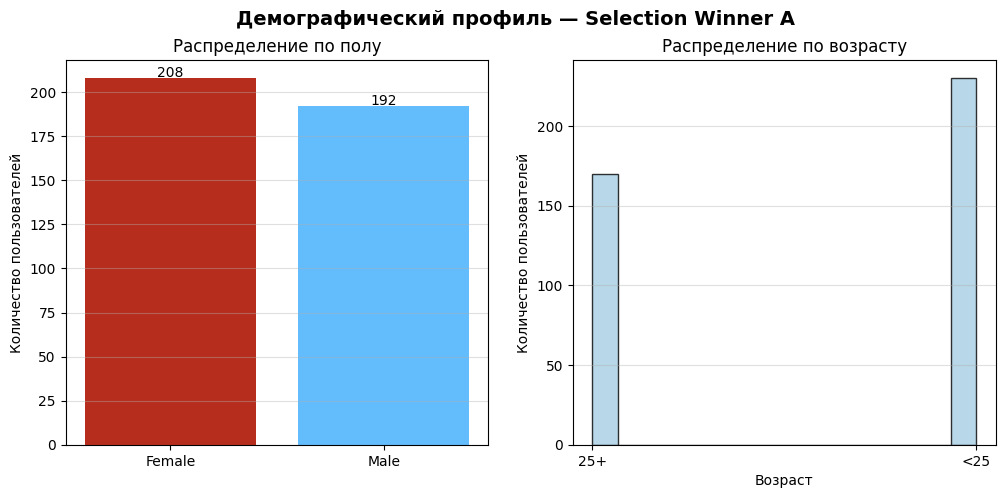

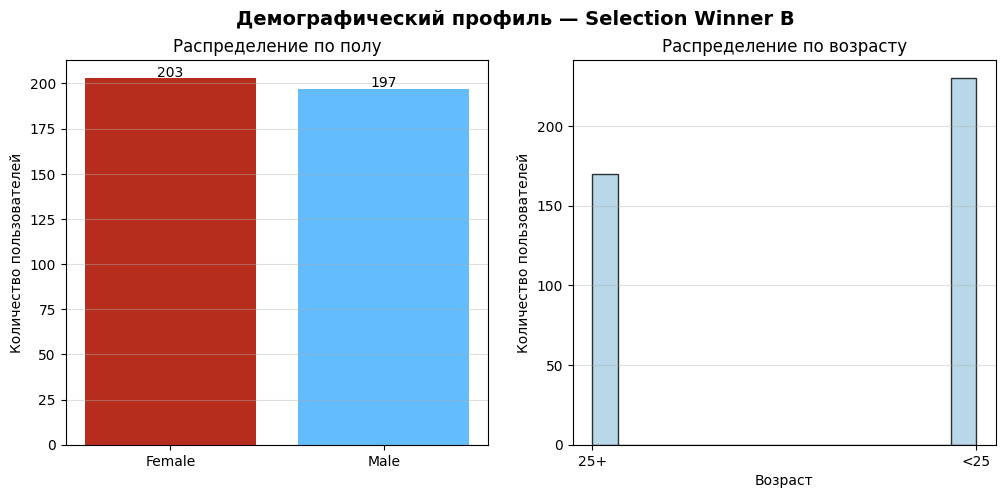

In [39]:
def plot_demographics(selection_col):
    subset = df[df[selection_col] == 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Демографический профиль — {selection_col}", fontsize=14, fontweight='bold')

    # Распределение пола
    gender_counts = subset['Gender'].value_counts()
    axes[0].bar(gender_counts.index, gender_counts.values, color=["#b72d1d", "#63bdfd"])
    axes[0].set_title("Распределение по полу")
    axes[0].set_ylabel("Количество пользователей")
    axes[0].grid(axis='y', alpha=0.4)
    for i, v in enumerate(gender_counts.values):
        axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

    # Распределение возраста
    axes[1].hist(subset['Age'], bins=15, color='#a6cee3', alpha=0.8, edgecolor='black')
    axes[1].set_title("Распределение по возрасту")
    axes[1].set_xlabel("Возраст")
    axes[1].set_ylabel("Количество пользователей")
    axes[1].grid(axis='y', alpha=0.4)
    plt.show()


plot_demographics('Selection Winner A')
plot_demographics('Selection Winner B')